# **HR Analytics Employee Attrition Analysis**

In [68]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Settings
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [9]:
df1 = pd.read_csv("/content/drive/MyDrive/Dataset/HR_Employee_Attrition.csv")

df1.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## **Data Inspection**

In [11]:
df1.shape

(1470, 35)

###**Observation**

There are 1470 employees and 35 features available for analysis.

In [12]:
df1.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [13]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [14]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [15]:
df1.isnull().sum()  # Check Missing Values


,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


The dataset is complete and does not require missing value treatment.

In [16]:
df1.duplicated().sum() # Check Duplicate Records

np.int64(0)

In [17]:
# Check Unique Values

for col in df1.columns:
    print(col)
    print(df1[col].unique())
    print("-"*50)


Age
[41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]
--------------------------------------------------
Attrition
['Yes' 'No']
--------------------------------------------------
BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
--------------------------------------------------
DailyRate
[1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371  673 1218  419  391  699 1282 1125  691
  477  705  924 1459  125  895  813 1273  869  890  852 1141  464 1240
 1357  994  721 1360 1065  408 1211 1229  626 1434 1488 1097 1443  515
  853 1142  655 1115  427  653  989 1435 1223  836 1195 1339  664  318
 1225 1328 1082  548  132  746  776  193  397  945 1214  111  573 1153
 1400  541  432  288  669  530  632 1334  638 1093 1217 1353  120  682
  489  807  827  871  665 1040 1420  240 1280  534 1456  658  142 1127
 1031 1189 1354 1467  922  394 1312  750  44

In [18]:
df1.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [19]:
df1.columns = df1.columns.str.strip()

In [20]:
df1.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

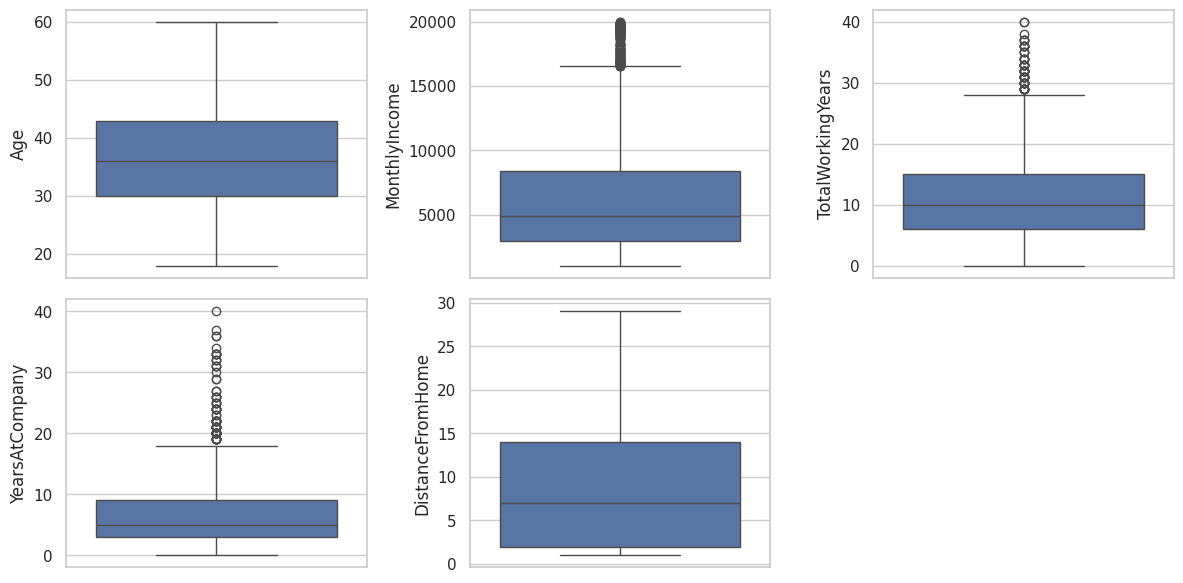

In [22]:
# Check Outliers only important numerical columns

num_cols = [
    'Age',
    'MonthlyIncome',
    'TotalWorkingYears',
    'YearsAtCompany',
    'DistanceFromHome'
]

plt.figure(figsize=(12,6))

for i,col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df1[col])

plt.tight_layout()
plt.show()

### **Observation**

Outliers exist.


## **Feature Engineering**

In [24]:
# Age Group

bins = [18,25,35,45,55,65]

labels = [
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56-65'
]

df1['AgeGroup'] = pd.cut(df1['Age'],
                        bins=bins,
                        labels=labels)

In [25]:
# Monthly Income Slab

def income_group(x):

    if x < 5000:
        return "Low"

    elif x < 10000:
        return "Medium"

    elif x < 15000:
        return "High"

    else:
        return "Very High"

df1['IncomeSlab'] = df1['MonthlyIncome'].apply(income_group)

In [26]:
# Experience Group

def experience(x):

    if x <= 5:
        return "0-5 Years"

    elif x <=10:
        return "6-10 Years"

    elif x <=20:
        return "11-20 Years"

    else:
        return "20+ Years"

df1['ExperienceGroup'] = df1['TotalWorkingYears'].apply(experience)

In [27]:
df1.to_csv("HR_Cleaned.csv", index=False)

### **HR_Cleaned Dataset**

In [30]:
df = pd.read_csv("/content/drive/MyDrive/Dataset/HR_Cleaned.csv")

df.head(2)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeGroup,IncomeSlab,ExperienceGroup
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,8,0,1,6,4,0,5,36-45,Medium,6-10 Years
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,10,3,3,10,7,1,7,46-55,Medium,6-10 Years


In [32]:
df.shape

(1470, 38)

###**Observation**

Now there are 38 features available for analysis.

-----------------------------------------

## **Exploratory Data Analysis (EDA)**

### 1. Target Variable Analysis (Attrition)

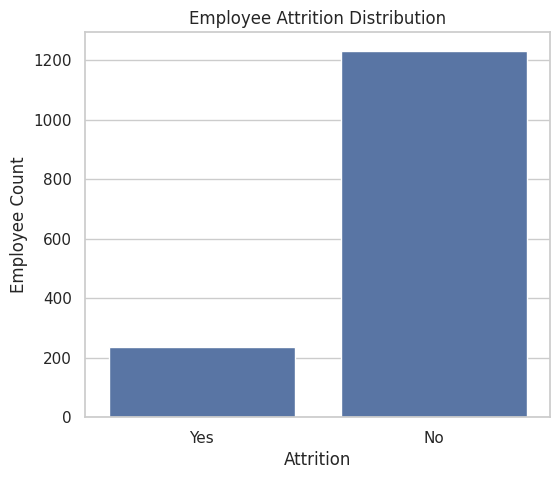

In [33]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Attrition')

plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Employee Count')

plt.show()

**Observation**

Most employees stayed, while a smaller portion left.

**Business Insight**

- Employee retention is generally good.

- However, the 16.12% attrition indicates there are specific employee groups with high turnover that require attention rather than company-wide interventions.

### Calculate Attrition Rate

In [34]:
attrition_rate = (df['Attrition'] == 'Yes').mean() * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


## **Executive Summary**

### **Overall Attrition Rate**

- **Attrition Rate = 16.12%**

### **Business Insight**

Around **1 out of every 6 employees leaves the company.**

This is a noticeable level of turnover that can increase:

- recruitment costs

- training expenses

- productivity loss

- knowledge loss

The rest of the analysis explains **why employees are leaving**.

### 2. Employee Distribution by Department

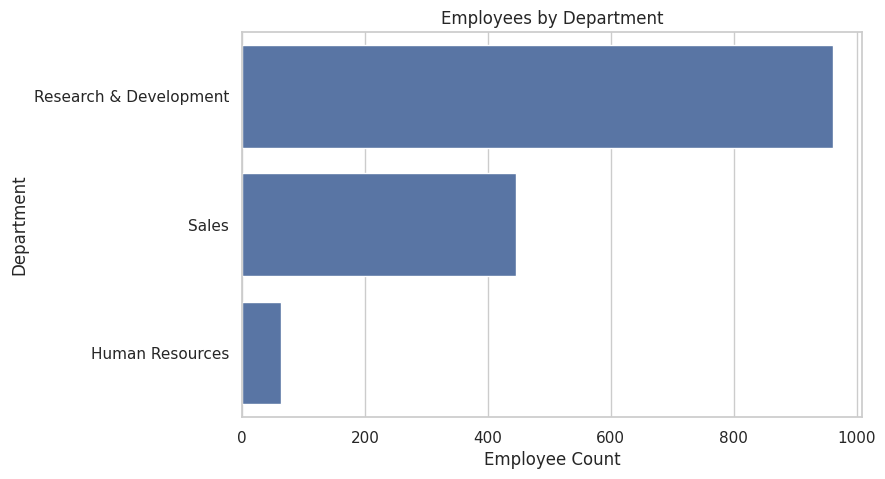

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              y='Department',
              order=df['Department'].value_counts().index)

plt.title('Employees by Department')
plt.xlabel('Employee Count')
plt.ylabel('Department')

plt.show()

**Observation**

Research & Development has the largest workforce.

**Business Insight**

- R&D is the backbone of the company.

- Even a moderate attrition percentage here can result in a large number of resignations.

- HR should prioritize retention strategies for this department.

### 3. Employee Distribution by Gender

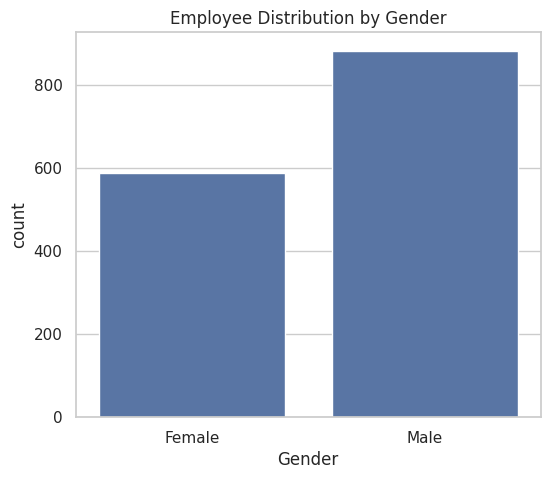

In [36]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Gender')

plt.title('Employee Distribution by Gender')

plt.show()

**Observation**

Male employees outnumber female employees.

**Business Insight**

- Workforce diversity is somewhat imbalanced.

- HR may explore diversity hiring initiatives while ensuring equal retention opportunities.

### 4.  Education Distribution

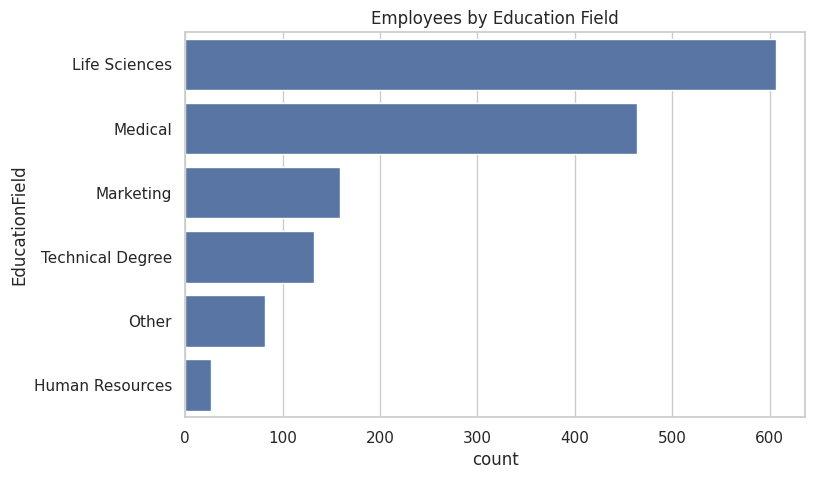

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y='EducationField',
    order=df['EducationField'].value_counts().index
)

plt.title('Employees by Education Field')

plt.show()

**Observation**

Life Sciences and Medical fields contribute the largest employee population.

**Business Insight**

- Recruitment heavily depends on these educational backgrounds.

- HR partnerships with universities offering these programs could strengthen the talent pipeline.

### 5. Job Role Distribution

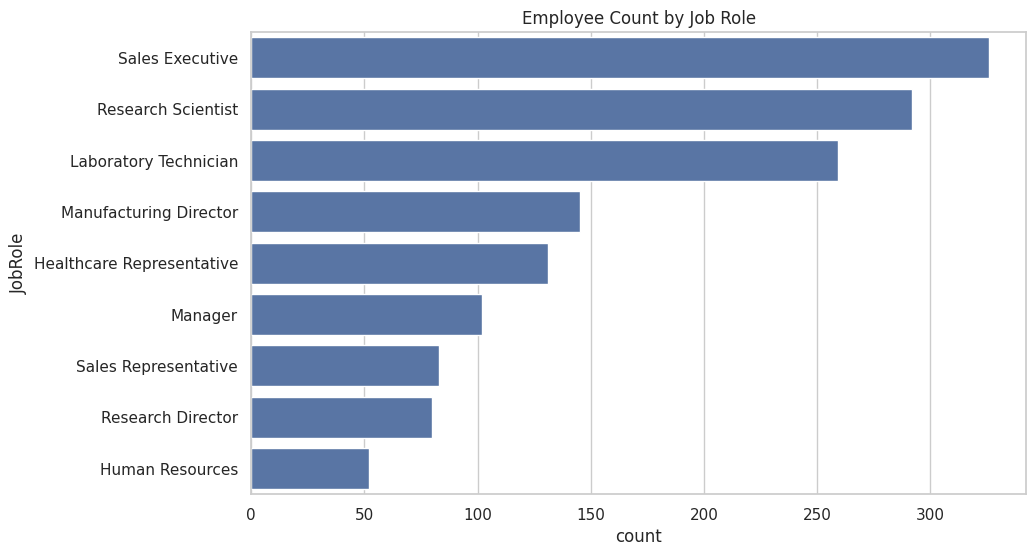

In [38]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y='JobRole',
    order=df['JobRole'].value_counts().index
)

plt.title('Employee Count by Job Role')

plt.show()

**Observation**

Sales Executive and Research Scientist are among the largest job roles.

**Business Insight**

- Since these roles employ many people, even average attrition rates can translate into significant employee losses.

- Retention initiatives should prioritize these high-volume positions.

### 6. Age Distribution

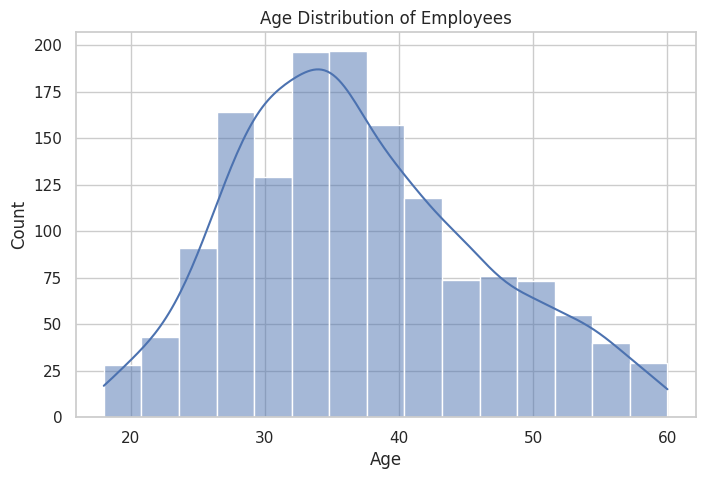

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=15, kde=True)

plt.title('Age Distribution of Employees')

plt.xlabel('Age')

plt.show()

**Observation**

Most employees are between 26–35 years old.

**Business Insight**

The workforce is relatively young.

Young professionals typically seek:

- career growth

- promotions

- salary progression

- learning opportunities

Providing these opportunities can improve retention.

### 7. Monthly Income Distribution

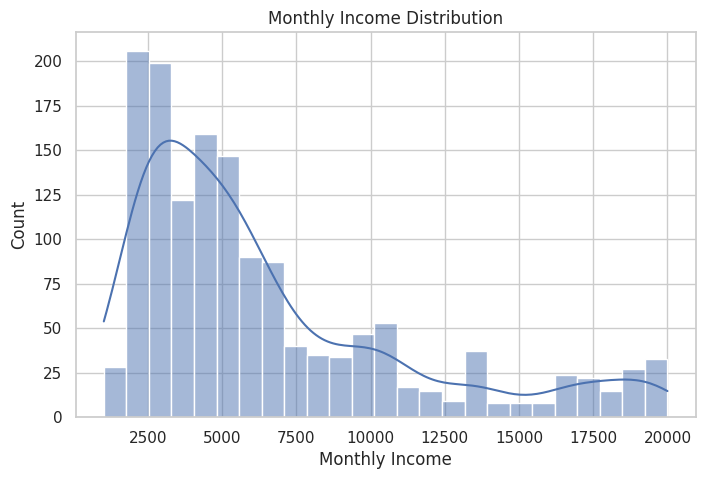

In [67]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyIncome'],
             bins=25,
             kde=True)

plt.title('Monthly Income Distribution')

plt.xlabel('Monthly Income')

plt.show()

**Observation**

Income distribution is positively skewed.

Most employees earn lower to mid-range salaries.

**Business Insight**

- Only a small percentage receive very high salaries.

- Compensation benchmarking should focus on lower-income employees who may be more likely to seek better-paying opportunities.

###8.  Attrition by Department

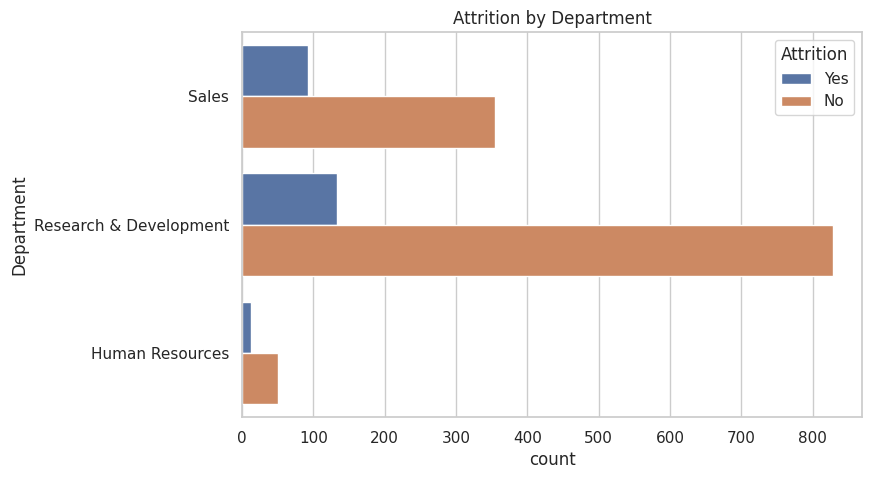

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y='Department',
    hue='Attrition'
)

plt.title('Attrition by Department')

plt.show()

**Observation**

Some departments experience noticeably higher attrition.

**Business Insight**

Possible reasons include:

- workload

- leadership

- promotion opportunities

- work pressure

HR should investigate department-specific issues rather than applying uniform retention policies.

###9. Attrition by Gender

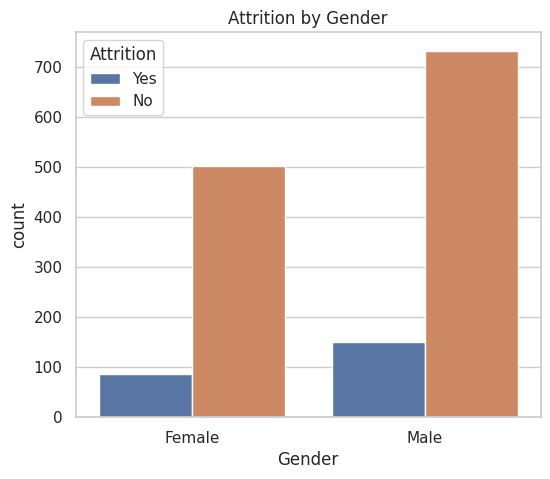

In [42]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Gender',
    hue='Attrition'
)

plt.title('Attrition by Gender')

plt.show()

**Observation**

One gender shows slightly higher attrition.

**Business Insight**

The difference appears relatively small.

Retention strategies should therefore focus more on workplace conditions than gender alone.

### 10. Attrition by Overtime ✅

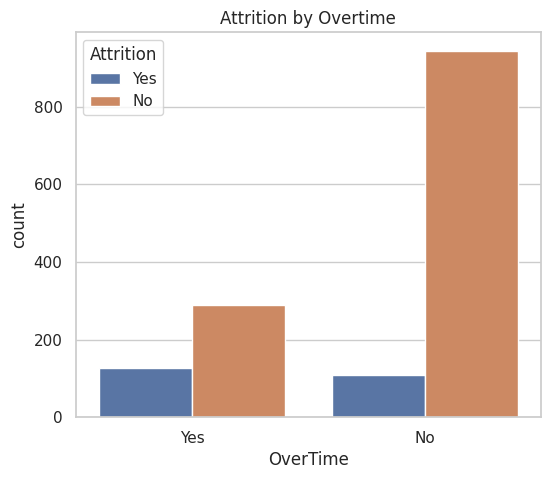

In [43]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='OverTime',
    hue='Attrition'
)

plt.title('Attrition by Overtime')

plt.show()

**Observation**

Employees working overtime leave significantly more often.

**Business Insight**

This indicates:

- workload imbalance

- employee burnout

- stress

- poor work-life balance

**HR Recommendation**

- Reduce unnecessary overtime.

- Improve workforce planning.

- Monitor manager workload allocation.

This is one of the strongest predictors of attrition.

###11. Attrition by Job Role

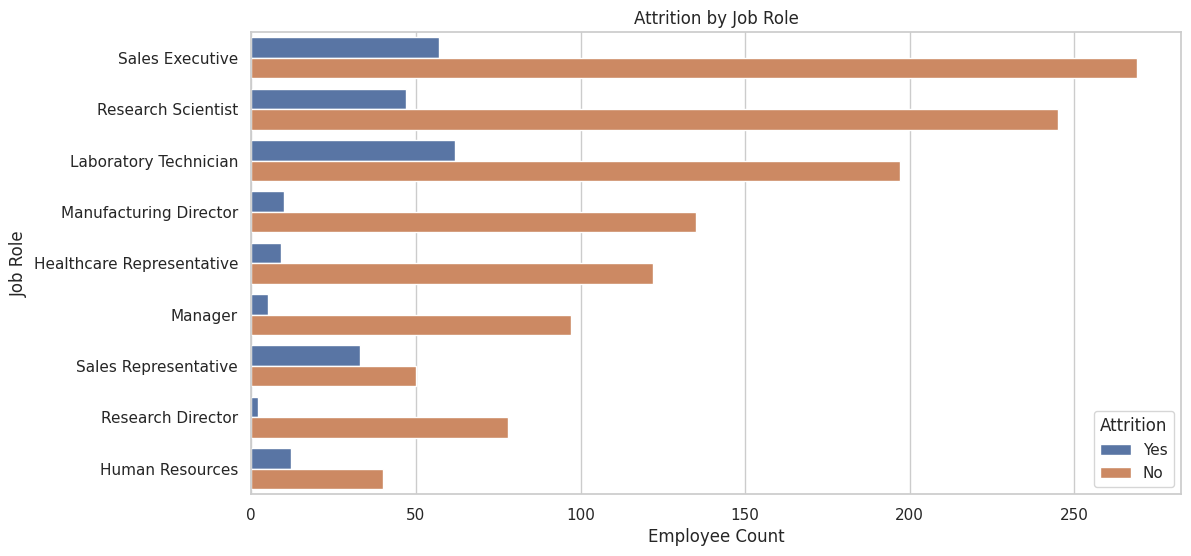

In [44]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='JobRole',
    hue='Attrition',
    order=df['JobRole'].value_counts().index
)

plt.title("Attrition by Job Role")
plt.xlabel("Employee Count")
plt.ylabel("Job Role")

plt.show()

**Observation**

Some job roles experience much higher turnover.

**Business Insight**

Possible causes:

- lower salary

- repetitive work

- fewer promotion opportunities

- higher performance pressure

HR should create role-specific retention plans.

### 12. Attrition by Age Group

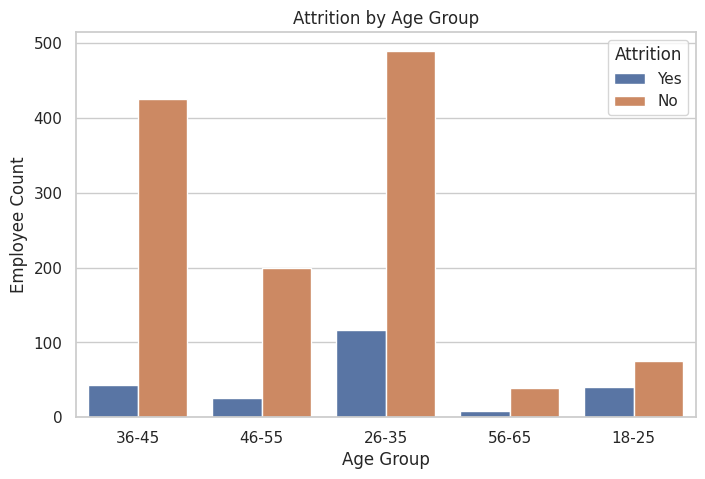

In [45]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='AgeGroup',
    hue='Attrition'
)

plt.title("Attrition by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Employee Count")

plt.show()

**Observation**

Young employees experience the highest attrition.

**Business Insight**

Employees in the early stages of their careers often:

- change jobs for salary growth

- seek better learning opportunities

- relocate

- pursue career advancement

Retention programs should target employees during their first few years.

### 13. Attrition by Income Slab ✅

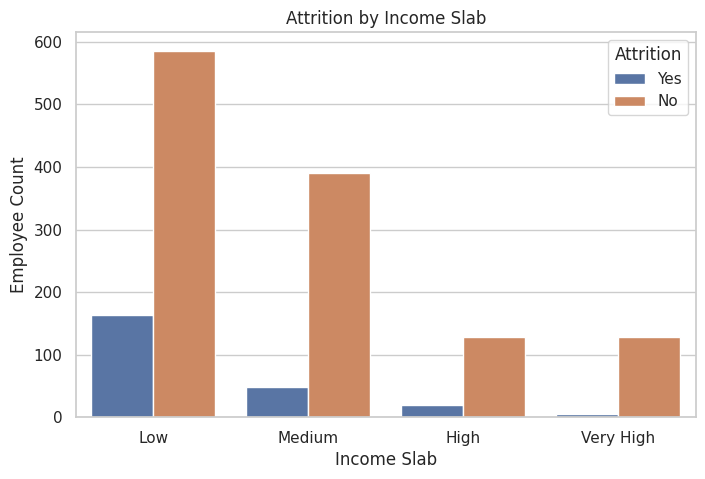

In [46]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='IncomeSlab',
    hue='Attrition',
    order=['Low','Medium','High','Very High']
)

plt.title("Attrition by Income Slab")
plt.xlabel("Income Slab")
plt.ylabel("Employee Count")

plt.show()

**Observation**

Employees in lower salary slabs leave more frequently.

**Business Insight**

Salary clearly influences employee retention.

Employees with lower compensation are more likely to switch companies.

**HR Recommendation**

- Review salary competitiveness.

- Introduce performance incentives.

- Strengthen career progression paths.

### 14. Attrition by Business Travel

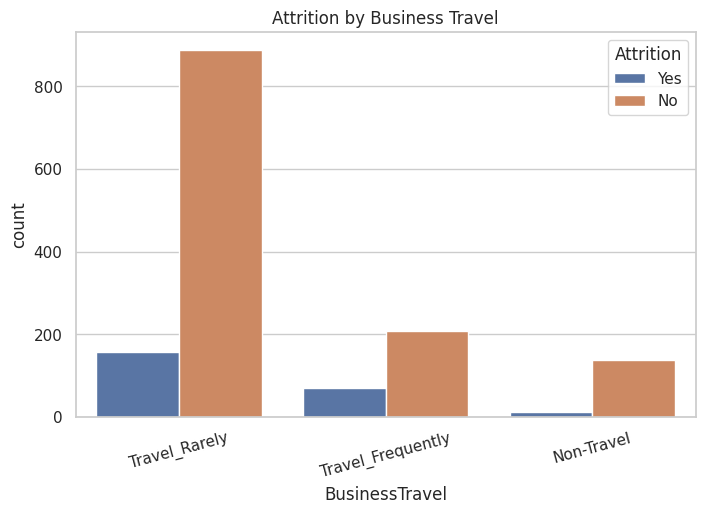

In [47]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='BusinessTravel',
    hue='Attrition'
)

plt.title("Attrition by Business Travel")
plt.xticks(rotation=15)

plt.show()

**Observation**

Employees who travel frequently have higher attrition.

**Business Insight**

Frequent travel may lead to:

- fatigue

- family-work conflict

- stress

HR should evaluate travel policies and provide additional support.

### 15. Attrition by Marital Status

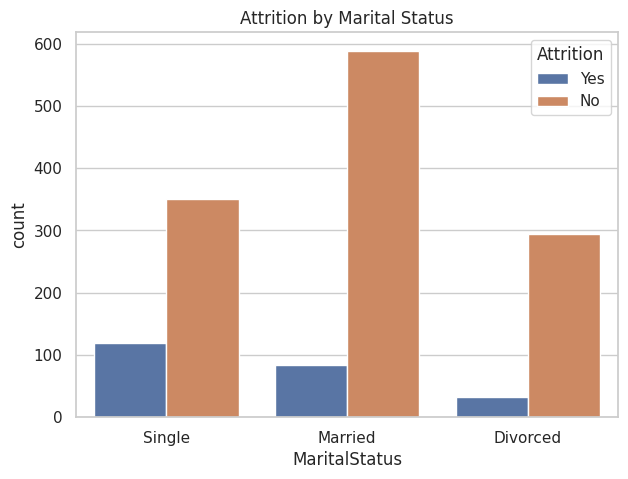

In [48]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='MaritalStatus',
    hue='Attrition'
)

plt.title("Attrition by Marital Status")

plt.show()

**Observation**

Single employees show higher attrition.

**Business Insight**

Single employees often have:

- fewer location constraints

- greater willingness to change jobs

- higher career mobility

Retention strategies for early-career professionals may be especially valuable.

###16. Job Satisfaction

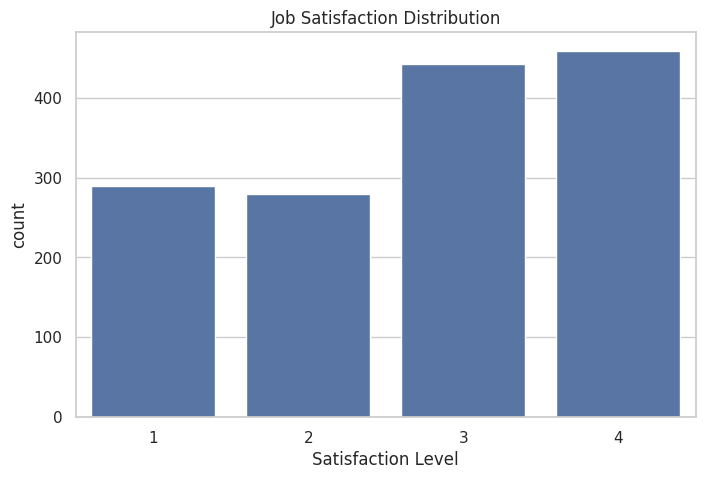

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='JobSatisfaction'
)

plt.title("Job Satisfaction Distribution")
plt.xlabel("Satisfaction Level")

plt.show()

**Observation**

Employees report varying satisfaction levels.

**Business Insight**

Lower job satisfaction often correlates with higher turnover.

HR should conduct regular employee engagement surveys.

###17. Environment Satisfaction

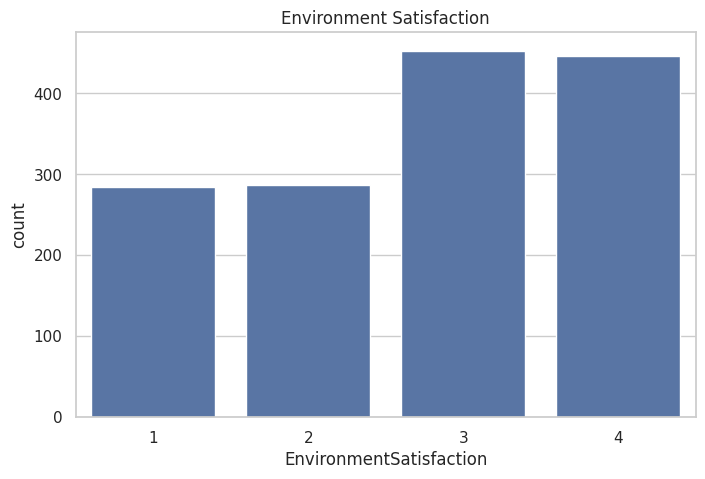

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='EnvironmentSatisfaction'
)

plt.title("Environment Satisfaction")

plt.show()

**Observation**

Workplace environment satisfaction varies across employees.

**Business Insight**

A positive work environment significantly influences retention.

Improving leadership quality, office culture, and communication can reduce turnover.

###18. Work-Life Balance

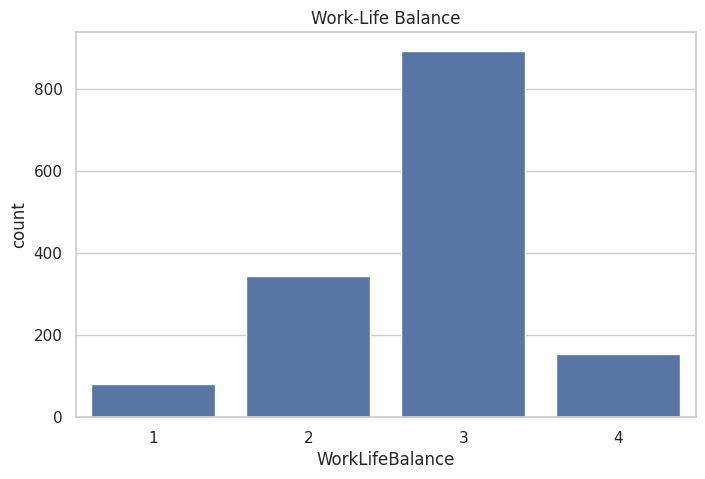

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='WorkLifeBalance'
)

plt.title("Work-Life Balance")

plt.show()

**Observation**

Employees reporting poor work-life balance tend to leave more frequently.

**Business Insight**

Poor balance contributes to:

- burnout
- stress
- disengagement

Flexible work policies could improve retention.

### 19. Years at Company

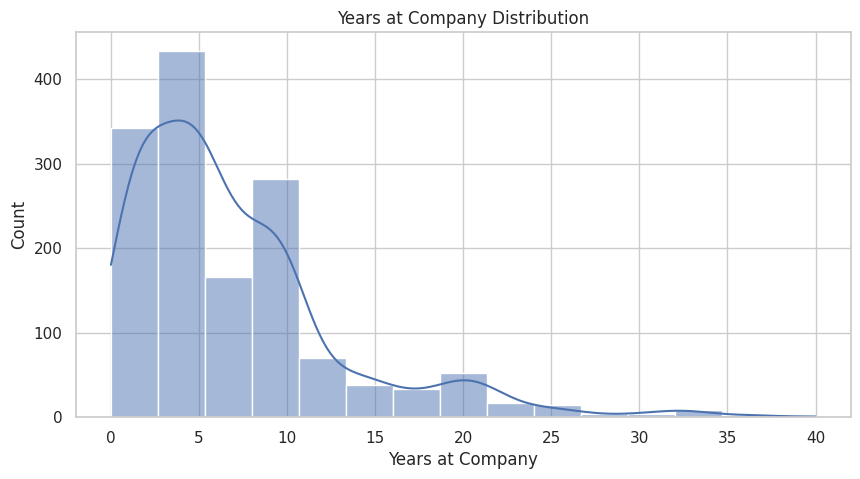

In [52]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['YearsAtCompany'],
    bins=15,
    kde=True
)

plt.title("Years at Company Distribution")
plt.xlabel("Years at Company")

plt.show()

**Observation**

Many employees have relatively short tenure.

**Business Insight**

The company hires successfully but struggles to retain employees over time.

The first few years appear to be the highest-risk period.

### 20. Correlation Heatmap

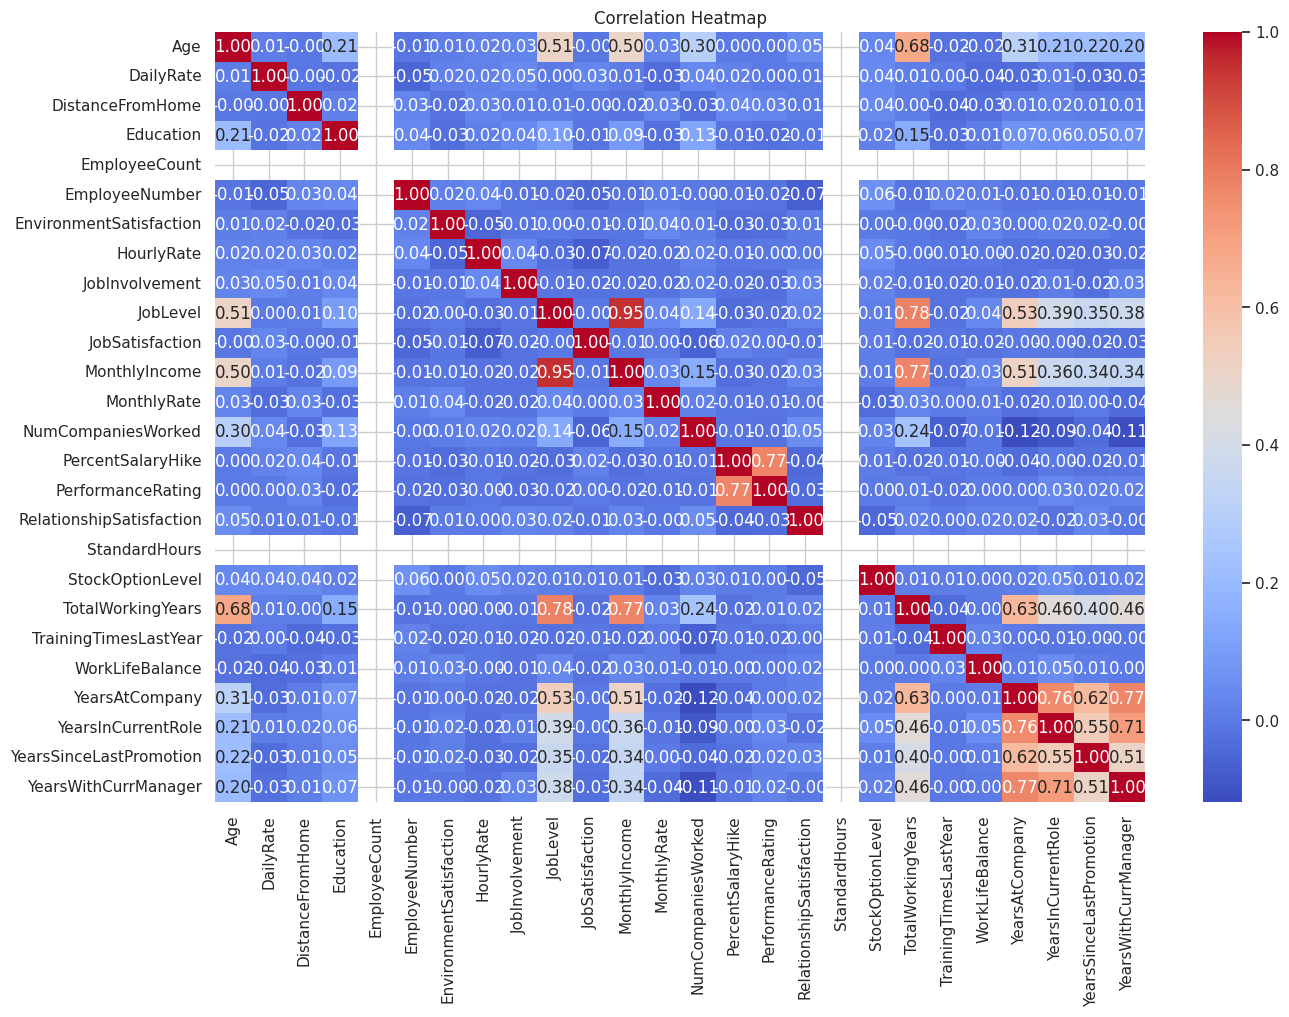

In [57]:
plt.figure(figsize=(15,10))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

**Observation**

Most numerical variables have only moderate correlations.

**Business Insight**

Employee attrition is influenced by multiple factors rather than a single variable.

This supports using multivariate analysis or predictive modeling for deeper insights.

<Axes: >

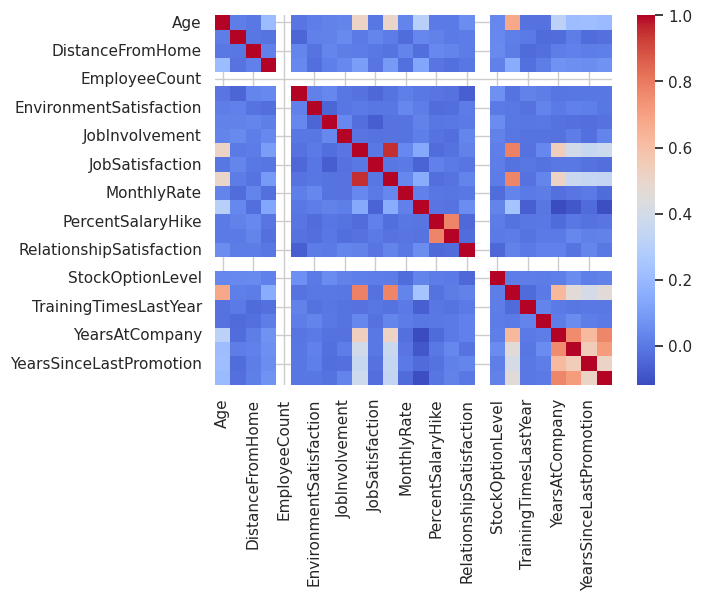

In [58]:
sns.heatmap(corr, cmap='coolwarm')

# ▶

## 21. Attrition by Job Satisfaction

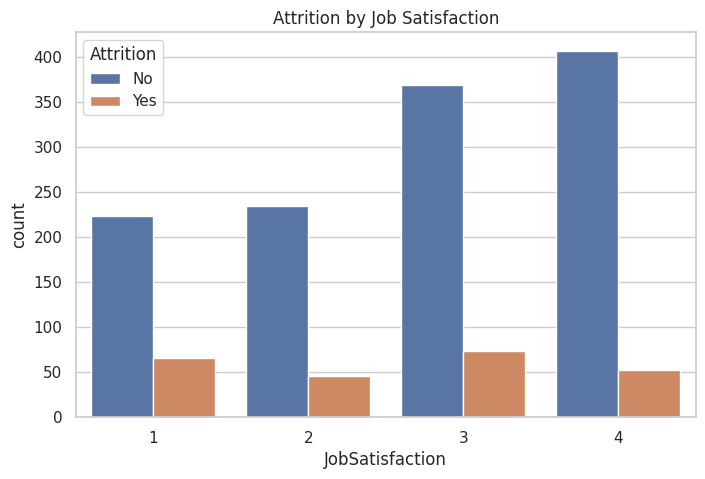

In [59]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='JobSatisfaction',
    hue='Attrition'
)

plt.title("Attrition by Job Satisfaction")

plt.show()

**Observation**

Employees with lower job satisfaction leave more frequently.

**Business Insight**

Job satisfaction is one of the strongest retention indicators.

HR should continuously monitor employee engagement.

##22. Attrition by Work-Life Balance

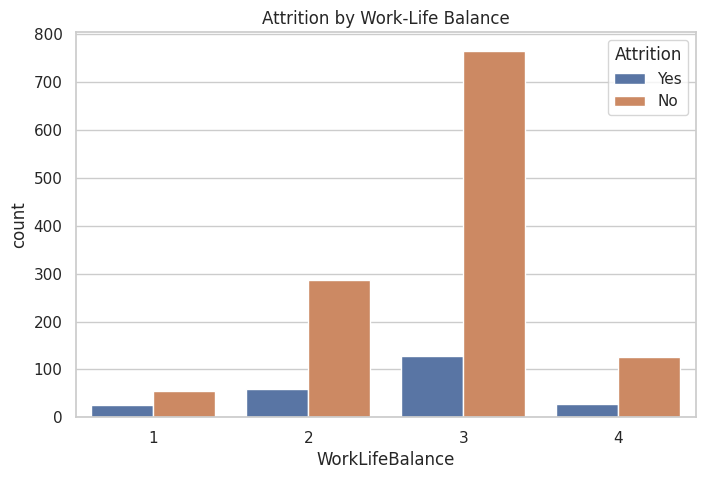

In [60]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='WorkLifeBalance',
    hue='Attrition'
)

plt.title("Attrition by Work-Life Balance")

plt.show()

**Observation**

Poor work-life balance aligns with higher attrition.

**Business Insight**

Flexible schedules, hybrid work options, and manageable workloads can improve retention.

##23. Attrition by Years Since Last Promotion

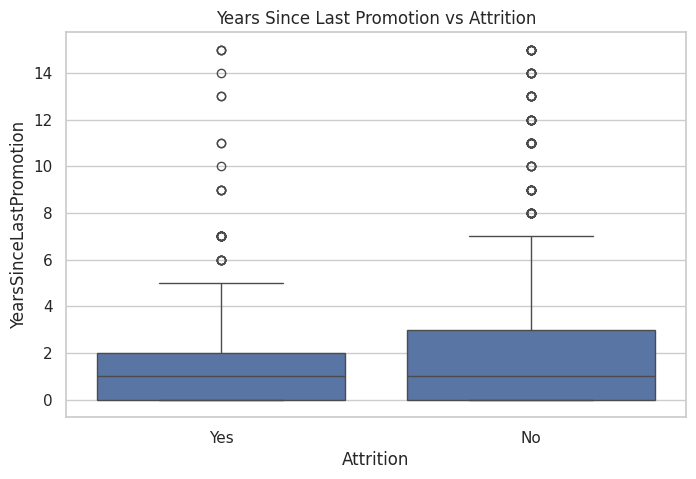

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Attrition',
    y='YearsSinceLastPromotion'
)

plt.title("Years Since Last Promotion vs Attrition")

plt.show()

**Observation**

Employees waiting many years for promotion show higher attrition.

**Business Insight**

Employees value career progression.

Lack of advancement opportunities increases resignation risk.

**Recommendation**

- Transparent promotion policies

- Career development plans

- Internal mobility programs

## 24. Monthly Income by Attrition

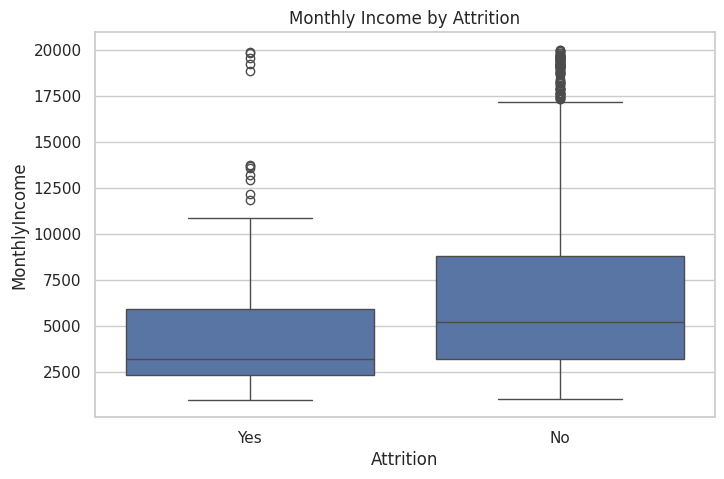

In [62]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Attrition',
    y='MonthlyIncome'
)

plt.title("Monthly Income by Attrition")

plt.show()

**Observation**

Employees who left generally have lower monthly incomes.

**Business Insight**

Compensation is a major driver of employee turnover.

Competitive salary benchmarking is essential.

### 25. Overtime vs Monthly Income

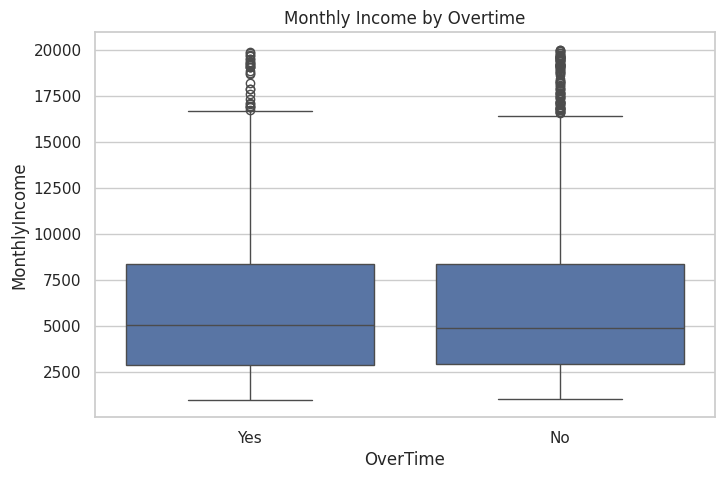

In [66]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='OverTime',
    y='MonthlyIncome'
)

plt.title("Monthly Income by Overtime")

plt.show()

**Observation**

Employees working overtime often earn varying incomes, but overtime remains associated with retention challenges.

**Business Insight**

Money alone cannot offset burnout.

Reducing excessive workload may be more effective than simply increasing compensation.

------------------------------

# **Overall Business Insights** ✈

Your notebook identifies several key drivers of attrition:

### **1. Overtime**

Excessive overtime is one of the strongest indicators of employee resignation.

### **2. Low Salary**

Lower-paid employees are significantly more likely to leave.

### **3. Young Employees**

Early-career professionals exhibit the highest turnover.

### **4. Limited Promotions**

Employees without recent promotions are at greater risk of attrition.

### **5. Poor Job Satisfaction**

Lower satisfaction levels strongly correlate with resignations.

### **6. Poor Work-Life Balance**

Employees experiencing imbalance are more likely to leave.

### **7. Frequent Business Travel**

Heavy travel demands increase employee turnover.

### **8. Department and Job Role**

Certain departments and job roles require targeted retention strategies.

-------------------------------------

# **Key HR Recommendations** ⚓

- Reduce unnecessary overtime through better workload planning.

- Benchmark salaries for lower-income employees.

- Strengthen career progression and promotion pathways.

- Focus retention programs on employees in their first 3–5 years.

- Improve work-life balance with flexible work arrangements.

- Conduct regular engagement and satisfaction surveys.

- Develop department-specific retention initiatives rather than a one-size-fits-all approach.

- Use predictive analytics to identify employees at high risk of leaving before resignation.